# # 练习1：SIR模型实现与参数分析
# 
# ## 学习目标
# 1. 实现SIR模型的数值求解
# 2. 可视化S、I、R随时间的变化
# 3. 分析不同R₀值对疫情发展的影响
# 4. 探讨防控措施的效果


In [1]:
# ## 1. 导入必要的库
import numpy as np
import pandas as pd
from scipy.integrate import odeint, solve_ivp
import matplotlib.pyplot as plt
import matplotlib as mpl
from IPython.display import display, HTML
import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False


# ## 2. SIR模型的数学定义

# ### 2.1 微分方程组
# 
# SIR模型由以下微分方程组描述：
# 
# $$\frac{dS}{dt} = -\beta \frac{SI}{N}$$
# 
# $$\frac{dI}{dt} = \beta \frac{SI}{N} - \gamma I$$
# 
# $$\frac{dR}{dt} = \gamma I$$
# 
# 其中：
# - S: 易感者人数 (Susceptible)
# - I: 感染者人数 (Infected)
# - R: 康复者人数 (Recovered)
# - N: 总人口
# - β: 接触率
# - γ: 康复率
# - R₀ = β/γ: 基本再生数


In [2]:
# ### 2.2 定义SIR模型函数

def sir_model(y, t, beta, gamma, N):
    """
    SIR模型的微分方程
    
    参数:
    y: [S, I, R] 当前状态
    t: 时间
    beta: 接触率
    gamma: 康复率
    N: 总人口
    
    返回:
    dydt: [dS/dt, dI/dt, dR/dt]
    """
    S, I, R = y
    
    dS_dt = -beta * S * I / N
    dI_dt = beta * S * I / N - gamma * I
    dR_dt = gamma * I
    
    return [dS_dt, dI_dt, dR_dt]

 ## 3. 基础模型求解与可视化

# ### 3.1 设置基础参数

In [3]:
 ## 3. 基础模型求解与可视化

# ### 3.1 设置基础参数

# 模型参数
N = 10000  # 总人口
I0 = 10    # 初始感染者
R0 = 0     # 初始康复者
S0 = N - I0 - R0  # 初始易感者

beta = 0.5   # 接触率
gamma = 0.1  # 康复率 (康复需要10天)

# 计算基本再生数
R_0 = beta / gamma
print(f"基本再生数 R₀ = {R_0:.2f}")

# 时间范围
t = np.linspace(0, 200, 1000)

# ### 3.2 求解微分方程

# 初始条件
y0 = [S0, I0, R0]


基本再生数 R₀ = 5.00


In [4]:
# 求解ODE
solution = odeint(sir_model, y0, t, args=(beta, gamma, N))

S, I, R = solution.T

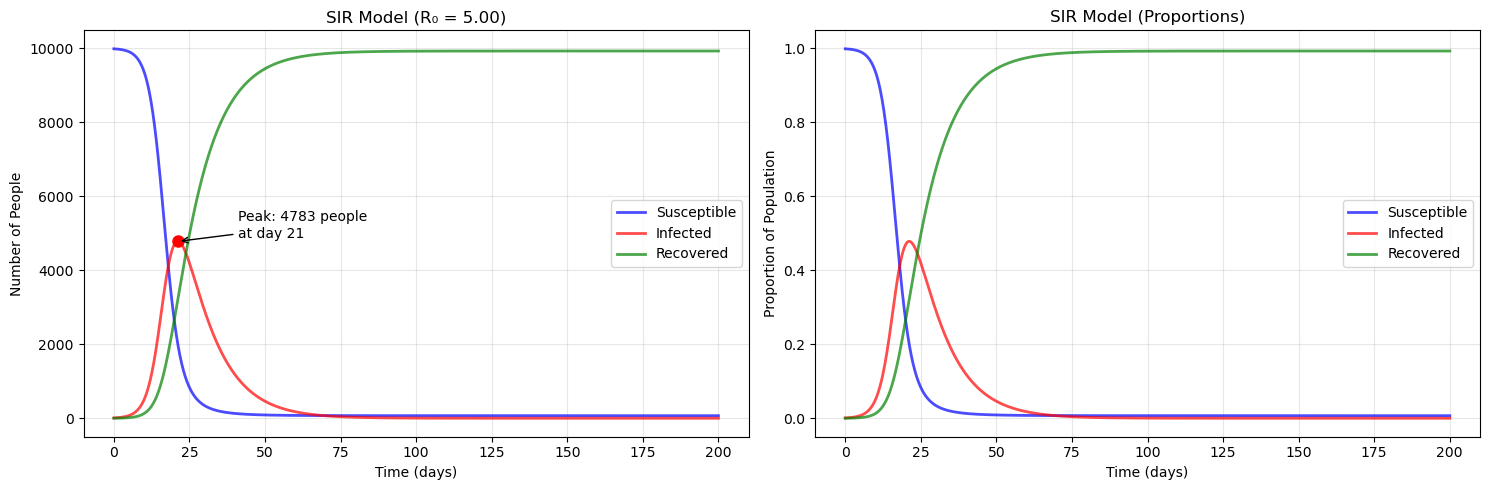

In [5]:
# ### 3.3 绘制基础SIR曲线

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# 左图：人数变化
ax1.plot(t, S, 'b-', alpha=0.7, linewidth=2, label='Susceptible')
ax1.plot(t, I, 'r-', alpha=0.7, linewidth=2, label='Infected')
ax1.plot(t, R, 'g-', alpha=0.7, linewidth=2, label='Recovered')

# 标记峰值
peak_idx = np.argmax(I)
ax1.plot(t[peak_idx], I[peak_idx], 'ro', markersize=8)
ax1.annotate(f'Peak: {I[peak_idx]:.0f} people\nat day {t[peak_idx]:.0f}',
            xy=(t[peak_idx], I[peak_idx]), 
            xytext=(t[peak_idx]+20, I[peak_idx]+100),
            arrowprops=dict(arrowstyle='->'))

ax1.set_xlabel('Time (days)')
ax1.set_ylabel('Number of People')
ax1.set_title(f'SIR Model (R₀ = {R_0:.2f})')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

# 右图：比例变化
ax2.plot(t, S/N, 'b-', alpha=0.7, linewidth=2, label='Susceptible')
ax2.plot(t, I/N, 'r-', alpha=0.7, linewidth=2, label='Infected')
ax2.plot(t, R/N, 'g-', alpha=0.7, linewidth=2, label='Recovered')

ax2.set_xlabel('Time (days)')
ax2.set_ylabel('Proportion of Population')
ax2.set_title('SIR Model (Proportions)')
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [6]:
# 输出关键统计
print(f"\n关键统计信息:")
print(f"疫情峰值: {I[peak_idx]:.0f} 人 (占总人口 {I[peak_idx]/N*100:.1f}%)")
print(f"峰值时间: 第 {t[peak_idx]:.0f} 天")
print(f"最终感染人数: {R[-1]:.0f} 人 (占总人口 {R[-1]/N*100:.1f}%)")
print(f"最终未感染人数: {S[-1]:.0f} 人 (占总人口 {S[-1]/N*100:.1f}%)")


关键统计信息:
疫情峰值: 4783 人 (占总人口 47.8%)
峰值时间: 第 21 天
最终感染人数: 9930 人 (占总人口 99.3%)
最终未感染人数: 70 人 (占总人口 0.7%)


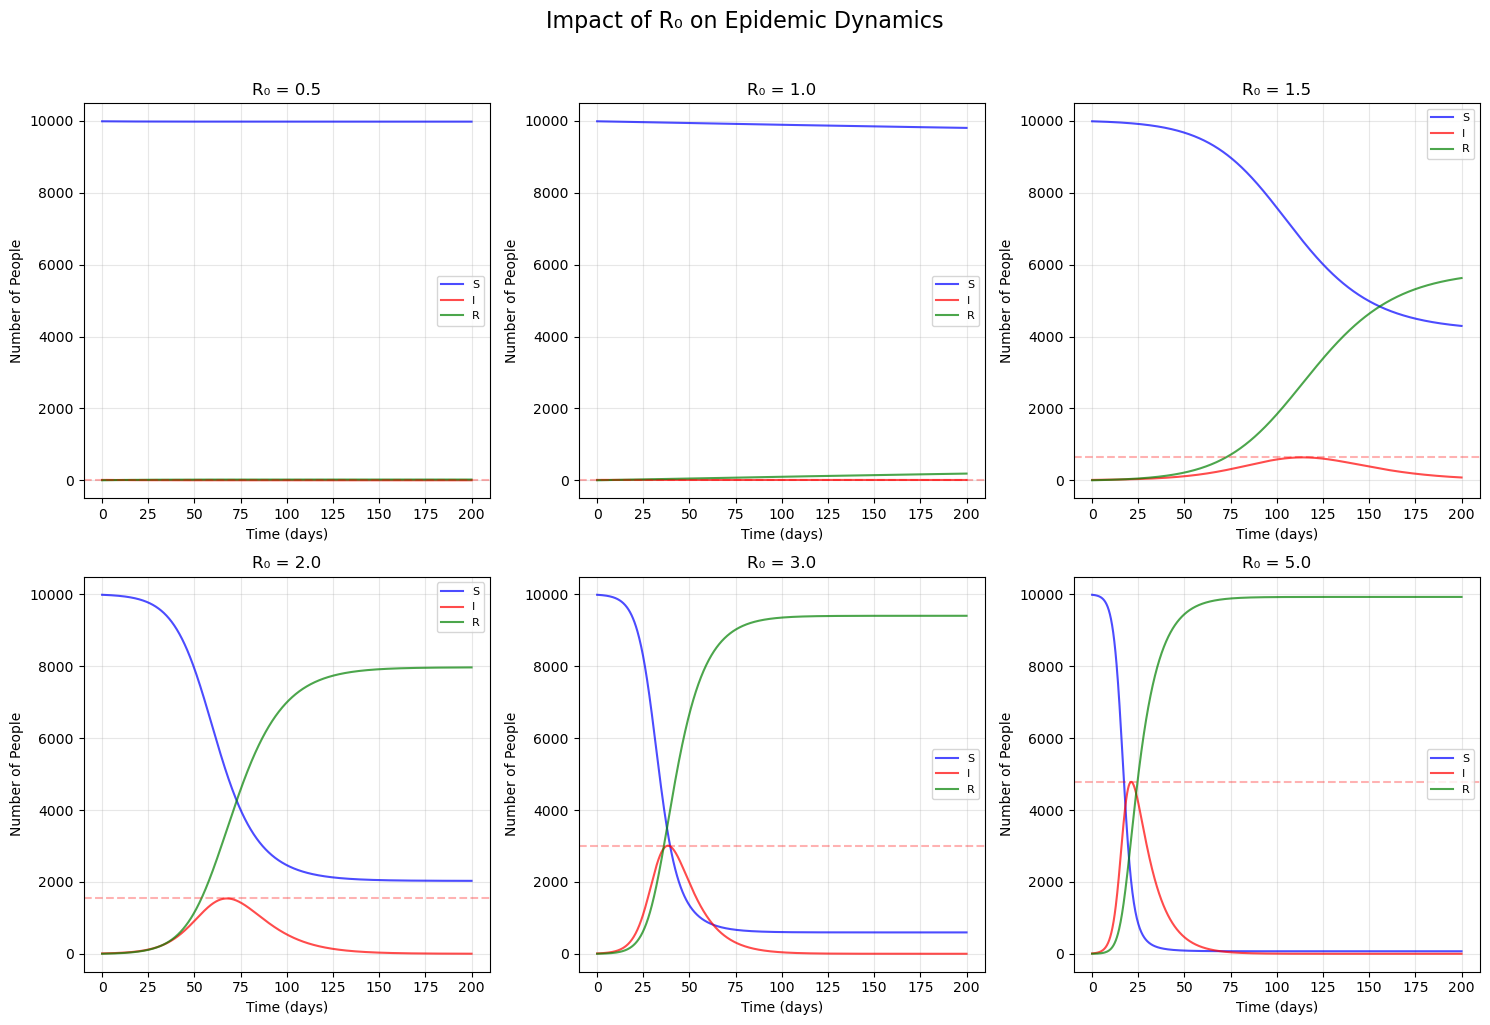

In [7]:
# ## 4. R₀对疫情发展的影响分析

# ### 4.1 不同R₀值的对比

# 定义不同的R₀值
R0_values = [0.5, 1.0, 1.5, 2.0, 3.0, 5.0]
gamma_fixed = 0.1  # 固定康复率

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

results_summary = []

for idx, R0_val in enumerate(R0_values):
    # 计算对应的beta
    beta_val = R0_val * gamma_fixed
    
    # 求解模型
    solution = odeint(sir_model, y0, t, args=(beta_val, gamma_fixed, N))
    S_temp, I_temp, R_temp = solution.T
    
    # 绘图
    ax = axes[idx]
    ax.plot(t, S_temp, 'b-', alpha=0.7, label='S')
    ax.plot(t, I_temp, 'r-', alpha=0.7, label='I')
    ax.plot(t, R_temp, 'g-', alpha=0.7, label='R')
    
    # 标记峰值
    peak_idx_temp = np.argmax(I_temp)
    ax.axhline(y=I_temp[peak_idx_temp], color='red', linestyle='--', alpha=0.3)
    
    ax.set_title(f'R₀ = {R0_val}')
    ax.set_xlabel('Time (days)')
    ax.set_ylabel('Number of People')
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)
    
    # 收集统计信息
    results_summary.append({
        'R₀': R0_val,
        'Peak Infections': I_temp[peak_idx_temp],
        'Peak Day': t[peak_idx_temp],
        'Total Infected': R_temp[-1],
        'Final Susceptible': S_temp[-1]
    })

plt.suptitle('Impact of R₀ on Epidemic Dynamics', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [8]:
# 显示统计表格
df_summary = pd.DataFrame(results_summary)
df_summary['Peak %'] = df_summary['Peak Infections'] / N * 100
df_summary['Total %'] = df_summary['Total Infected'] / N * 100

print("\n不同R₀值的疫情统计:")
print(df_summary.round(1))


不同R₀值的疫情统计:
    R₀  Peak Infections  Peak Day  Total Infected  Final Susceptible  Peak %  \
0  0.5             10.0       0.0            20.0             9980.0     0.1   
1  1.0             10.0       0.0           186.0             9805.9     0.1   
2  1.5            636.9     113.9          5627.5             4295.0     6.4   
3  2.0           1539.2      67.7          7968.8             2029.6    15.4   
4  3.0           3007.9      38.4          9405.5              594.5    30.1   
5  5.0           4782.9      21.2          9930.3               69.7    47.8   

   Total %  
0      0.2  
1      1.9  
2     56.3  
3     79.7  
4     94.1  
5     99.3  


In [9]:
# ### 4.2 R₀临界值分析

# R₀从0.5到5的连续变化
R0_range = np.linspace(0.5, 5, 50)
final_infected = []
peak_infections = []

for R0_val in R0_range:
    beta_val = R0_val * gamma_fixed
    solution = odeint(sir_model, y0, t, args=(beta_val, gamma_fixed, N))
    S_temp, I_temp, R_temp = solution.T
    
    final_infected.append(R_temp[-1] / N * 100)
    peak_infections.append(np.max(I_temp) / N * 100)

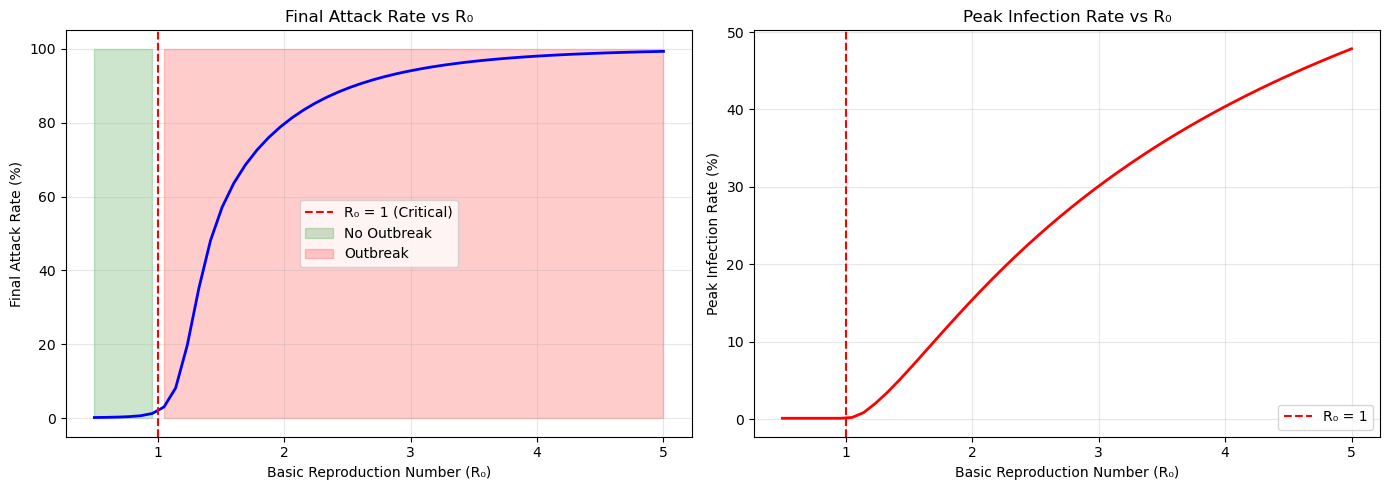

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 最终感染比例 vs R₀
ax1.plot(R0_range, final_infected, 'b-', linewidth=2)
ax1.axvline(x=1, color='red', linestyle='--', label='R₀ = 1 (Critical)')
ax1.fill_between(R0_range[R0_range < 1], 0, 100, alpha=0.2, color='green', label='No Outbreak')
ax1.fill_between(R0_range[R0_range >= 1], 0, 100, alpha=0.2, color='red', label='Outbreak')
ax1.set_xlabel('Basic Reproduction Number (R₀)')
ax1.set_ylabel('Final Attack Rate (%)')
ax1.set_title('Final Attack Rate vs R₀')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 峰值感染比例 vs R₀
ax2.plot(R0_range, peak_infections, 'r-', linewidth=2)
ax2.axvline(x=1, color='red', linestyle='--', label='R₀ = 1')
ax2.set_xlabel('Basic Reproduction Number (R₀)')
ax2.set_ylabel('Peak Infection Rate (%)')
ax2.set_title('Peak Infection Rate vs R₀')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
# ## 5. 防控措施效果分析

# ### 5.1 不同时间开始防控的效果

def sir_model_with_intervention(y, t, beta, gamma, N, t_intervention, reduction_factor):
    """带有干预措施的SIR模型"""
    S, I, R = y
    
    # 在干预时间后降低接触率
    if t >= t_intervention:
        beta_effective = beta * (1 - reduction_factor)
    else:
        beta_effective = beta
    
    dS_dt = -beta_effective * S * I / N
    dI_dt = beta_effective * S * I / N - gamma * I
    dR_dt = gamma * I
    
    return [dS_dt, dI_dt, dR_dt]


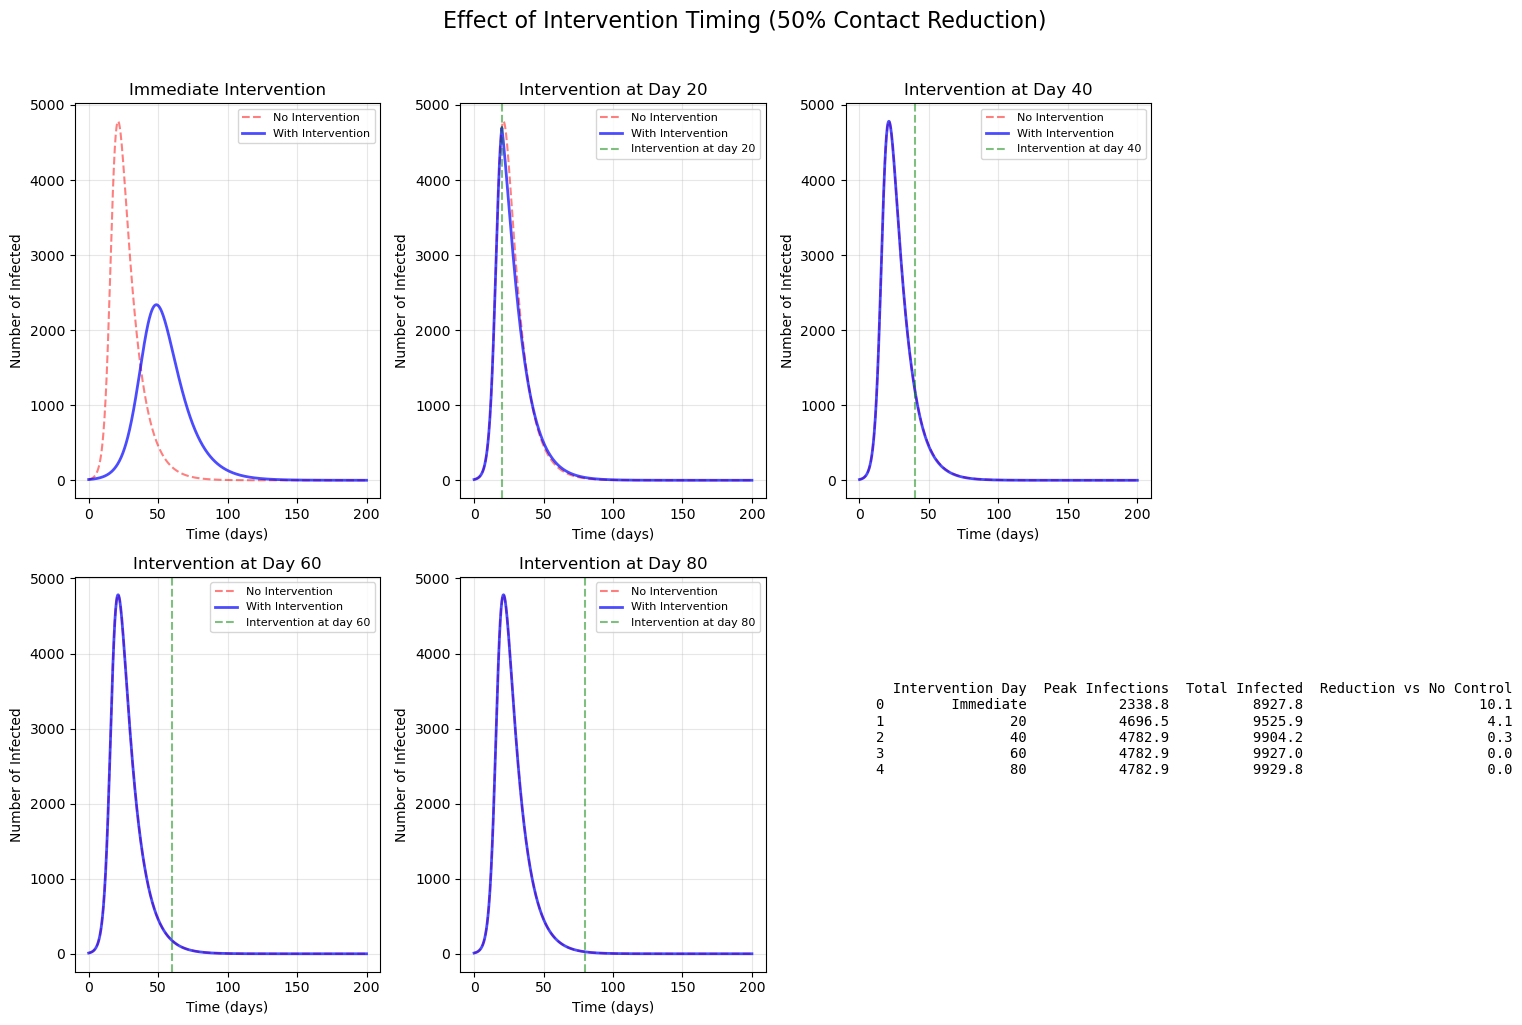

In [22]:
# 设置参数
intervention_days = [0, 20, 40, 60, 80]  # 不同的干预开始时间
reduction = 0.5  # 降低50%的接触率

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# 无干预的基准情况
solution_base = odeint(sir_model, y0, t, args=(beta, gamma, N))
S_base, I_base, R_base = solution_base.T

intervention_results = []
for idx, t_int in enumerate(intervention_days):
    # 求解带干预的模型
    solution = odeint(sir_model_with_intervention, y0, t, 
                      args=(beta, gamma, N, t_int, reduction))
    S_temp, I_temp, R_temp = solution.T
    
    # 绘图
    ax = axes[idx]
    ax.plot(t, I_base, 'r--', alpha=0.5, label='No Intervention')
    ax.plot(t, I_temp, 'b-', alpha=0.7, linewidth=2, label='With Intervention')
    
    if t_int > 0:
        ax.axvline(x=t_int, color='green', linestyle='--', alpha=0.5, 
                  label=f'Intervention at day {t_int}')
    
    ax.set_title(f'Intervention at Day {t_int}' if t_int > 0 else 'Immediate Intervention')
    ax.set_xlabel('Time (days)')
    ax.set_ylabel('Number of Infected')
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)
    
    # 收集结果
    intervention_results.append({
        'Intervention Day': t_int if t_int > 0 else 'Immediate',
        'Peak Infections': np.max(I_temp),
        'Total Infected': R_temp[-1],
        'Reduction vs No Control': (R_base[-1] - R_temp[-1]) / R_base[-1] * 100
    })

# 最后一个子图显示总结
ax = axes[-1]
ax.axis('off')
df_intervention = pd.DataFrame(intervention_results)
table_text = df_intervention.round(1).to_string()
ax.text(0.1, 0.5, table_text, fontsize=10, family='monospace')

plt.suptitle('Effect of Intervention Timing (50% Contact Reduction)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

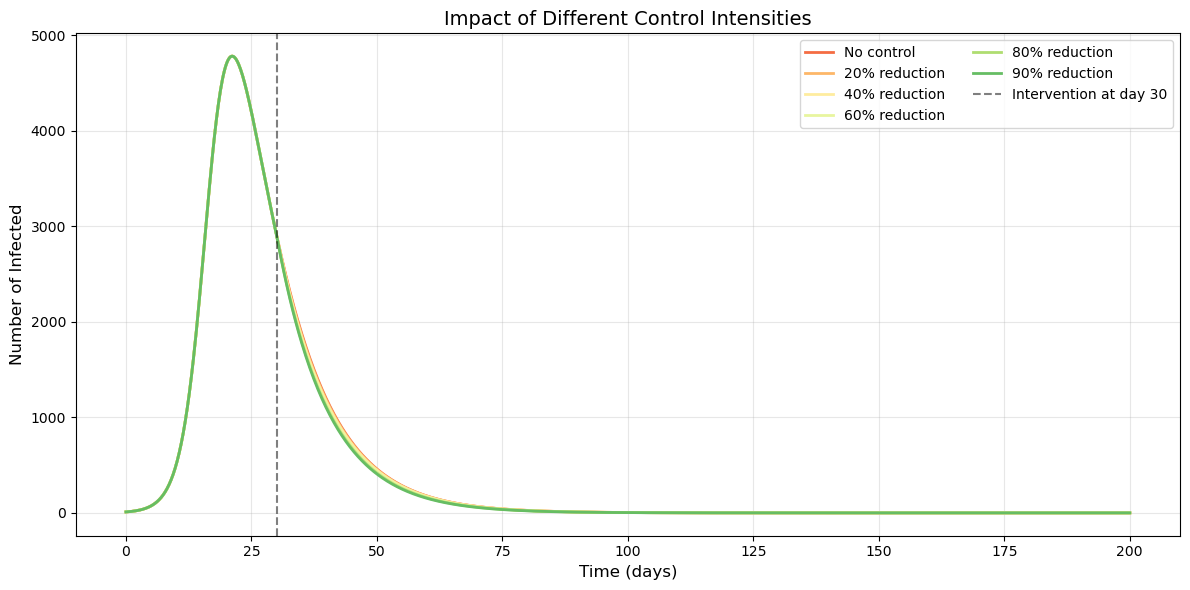

In [14]:
# ### 5.2 不同防控强度的效果

reduction_levels = [0, 0.2, 0.4, 0.6, 0.8, 0.9]  # 不同的防控强度
t_intervention = 30  # 固定在第30天开始防控

fig, ax = plt.subplots(figsize=(12, 6))

colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(reduction_levels)))

for idx, reduction in enumerate(reduction_levels):
    solution = odeint(sir_model_with_intervention, y0, t, 
                     args=(beta, gamma, N, t_intervention, reduction))
    S_temp, I_temp, R_temp = solution.T
    
    label = f'{reduction*100:.0f}% reduction' if reduction > 0 else 'No control'
    ax.plot(t, I_temp, color=colors[idx], linewidth=2, label=label)

ax.axvline(x=t_intervention, color='black', linestyle='--', alpha=0.5, 
          label=f'Intervention at day {t_intervention}')
ax.set_xlabel('Time (days)', fontsize=12)
ax.set_ylabel('Number of Infected', fontsize=12)
ax.set_title('Impact of Different Control Intensities', fontsize=14)
ax.legend(loc='best', ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
# ## 6. 交互式SIR模型探索

# ### 6.1 创建交互式控件

print("### 交互式SIR模型参数探索")
print("调整下方滑块来观察参数变化对疫情的影响：\n")

def interactive_sir(beta_val, gamma_val, I0_val, control_day, control_strength):
    """交互式SIR模型函数"""
    
    # 初始条件
    S0_int = N - I0_val
    I0_int = I0_val
    R0_int = 0
    y0_int = [S0_int, I0_int, R0_int]
    
    # 计算R₀
    R0_calculated = beta_val / gamma_val
    
    # 求解模型
    if control_day < 200:  # 有防控措施
        solution = odeint(sir_model_with_intervention, y0_int, t, 
                         args=(beta_val, gamma_val, N, control_day, control_strength))
    else:  # 无防控措施
        solution = odeint(sir_model, y0_int, t, args=(beta_val, gamma_val, N))
    
    S_temp, I_temp, R_temp = solution.T
    
    # 创建图形
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # 左图：SIR曲线
    ax1.plot(t, S_temp, 'b-', linewidth=2, label='Susceptible')
    ax1.plot(t, I_temp, 'r-', linewidth=2, label='Infected')
    ax1.plot(t, R_temp, 'g-', linewidth=2, label='Recovered')
    
    if control_day < 200:
        ax1.axvline(x=control_day, color='purple', linestyle='--', alpha=0.5,
                   label=f'Control at day {control_day}')
    
    # 标记峰值
    peak_idx = np.argmax(I_temp)
    ax1.plot(t[peak_idx], I_temp[peak_idx], 'ro', markersize=8)
    
    ax1.set_xlabel('Time (days)')
    ax1.set_ylabel('Number of People')
    ax1.set_title(f'SIR Model (R₀ = {R0_calculated:.2f})')
    ax1.legend(loc='best')
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim([0, N])
    
    # 右图：相平面图
    ax2.plot(S_temp/N, I_temp/N, 'k-', linewidth=2)
    ax2.plot(S_temp[0]/N, I_temp[0]/N, 'go', markersize=10, label='Start')
    ax2.plot(S_temp[-1]/N, I_temp[-1]/N, 'ro', markersize=10, label='End')
    
    # 添加向量场
    S_grid = np.linspace(0, 1, 20)
    I_grid = np.linspace(0, 0.3, 15)
    S_mesh, I_mesh = np.meshgrid(S_grid, I_grid)
    
    dS_mesh = -beta_val * S_mesh * I_mesh
    dI_mesh = beta_val * S_mesh * I_mesh - gamma_val * I_mesh
    
    ax2.quiver(S_mesh, I_mesh, dS_mesh, dI_mesh, alpha=0.3)
    
    ax2.set_xlabel('Susceptible Fraction (S/N)')
    ax2.set_ylabel('Infected Fraction (I/N)')
    ax2.set_title('Phase Plane')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 打印统计信息
    print(f"\n统计信息:")
    print(f"基本再生数 R₀ = {R0_calculated:.2f}")
    print(f"峰值感染人数: {I_temp[peak_idx]:.0f} ({I_temp[peak_idx]/N*100:.1f}%)")
    print(f"峰值时间: 第 {t[peak_idx]:.0f} 天")
    print(f"最终感染总数: {R_temp[-1]:.0f} ({R_temp[-1]/N*100:.1f}%)")
    
    if control_day < 200:
        # 计算无控制情况
        solution_no_control = odeint(sir_model, y0_int, t, args=(beta_val, gamma_val, N))
        R_no_control = solution_no_control[:, 2]
        reduction_percent = (R_no_control[-1] - R_temp[-1]) / R_no_control[-1] * 100
        print(f"防控措施减少感染: {reduction_percent:.1f}%")

# 创建交互式控件
interact(interactive_sir,
         beta_val=widgets.FloatSlider(value=0.5, min=0.1, max=1.0, step=0.05, 
                                      description='β (接触率):', style={'description_width': 'initial'}),
         gamma_val=widgets.FloatSlider(value=0.1, min=0.05, max=0.5, step=0.05, 
                                       description='γ (康复率):', style={'description_width': 'initial'}),
         I0_val=widgets.IntSlider(value=10, min=1, max=100, step=5, 
                                  description='初始感染者:', style={'description_width': 'initial'}),
         control_day=widgets.IntSlider(value=200, min=0, max=200, step=10, 
                                       description='防控开始日:', style={'description_width': 'initial'}),
         control_strength=widgets.FloatSlider(value=0.5, min=0, max=0.9, step=0.1, 
                                              description='防控强度:', style={'description_width': 'initial'}))

### 交互式SIR模型参数探索
调整下方滑块来观察参数变化对疫情的影响：



interactive(children=(FloatSlider(value=0.5, description='β (接触率):', max=1.0, min=0.1, step=0.05, style=Slider…

<function __main__.interactive_sir(beta_val, gamma_val, I0_val, control_day, control_strength)>

In [24]:
# ## 7. 群体免疫阈值分析

# ### 7.1 计算群体免疫阈值

print("\n## 群体免疫阈值分析\n")

def herd_immunity_threshold(R0):
    """计算群体免疫阈值"""
    if R0 <= 1:
        return 0
    return 1 - 1/R0

# 不同疾病的R₀值
diseases = {
    'Measles (麻疹)': 15,
    'Chickenpox (水痘)': 10,
    'Mumps (腮腺炎)': 7,
    'COVID-19 (Delta)': 6,
    'COVID-19 (Original)': 2.5,
    'SARS': 3,
    'Seasonal Flu': 1.5,
    'Common Cold': 2
}

# 计算每种疾病的群体免疫阈值
herd_immunity_data = []
for disease, r0 in diseases.items():
    threshold = herd_immunity_threshold(r0)
    herd_immunity_data.append({
        'Disease': disease,
        'R₀': r0,
        'Herd Immunity Threshold': f'{threshold*100:.1f}%'
    })

df_herd = pd.DataFrame(herd_immunity_data)
df_herd = df_herd.sort_values('R₀', ascending=False)

print("不同疾病的群体免疫阈值:")
print(df_herd.to_string(index=False))


## 群体免疫阈值分析

不同疾病的群体免疫阈值:
            Disease   R₀ Herd Immunity Threshold
       Measles (麻疹) 15.0                   93.3%
    Chickenpox (水痘) 10.0                   90.0%
        Mumps (腮腺炎)  7.0                   85.7%
   COVID-19 (Delta)  6.0                   83.3%
               SARS  3.0                   66.7%
COVID-19 (Original)  2.5                   60.0%
        Common Cold  2.0                   50.0%
       Seasonal Flu  1.5                   33.3%


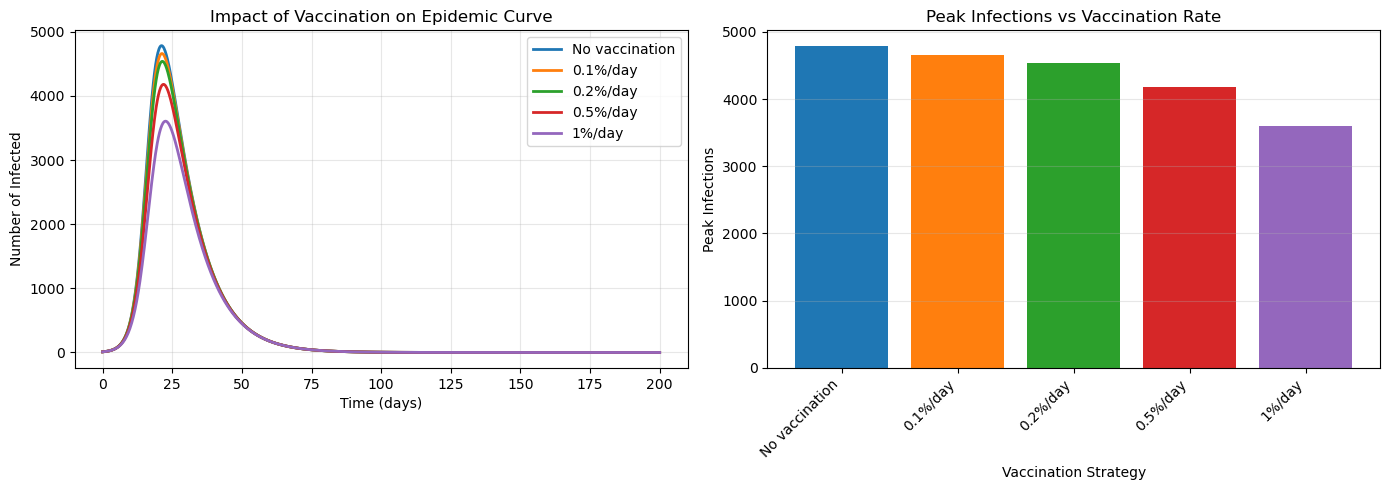

In [25]:
# ### 7.2 疫苗接种策略模拟

def sir_model_with_vaccination(y, t, beta, gamma, N, vaccination_rate):
    """带疫苗接种的SIR模型"""
    S, I, R = y
    
    # 疫苗接种：易感者直接变成康复者
    dS_dt = -beta * S * I / N - vaccination_rate * S
    dI_dt = beta * S * I / N - gamma * I
    dR_dt = gamma * I + vaccination_rate * S
    
    return [dS_dt, dI_dt, dR_dt]

# 模拟不同疫苗接种率
vaccination_rates = [0, 0.001, 0.002, 0.005, 0.01]  # 每天接种比例
labels = ['No vaccination', '0.1%/day', '0.2%/day', '0.5%/day', '1%/day']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for idx, (vac_rate, label) in enumerate(zip(vaccination_rates, labels)):
    solution = odeint(sir_model_with_vaccination, y0, t, 
                     args=(beta, gamma, N, vac_rate))
    S_temp, I_temp, R_temp = solution.T
    
    ax1.plot(t, I_temp, linewidth=2, label=label)
    
    # 计算最终感染率
    final_infected = np.max(R_temp) - vac_rate * N * t[-1]  # 减去疫苗接种的人数
    ax2.bar(idx, np.max(I_temp), label=label)

ax1.set_xlabel('Time (days)')
ax1.set_ylabel('Number of Infected')
ax1.set_title('Impact of Vaccination on Epidemic Curve')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Vaccination Strategy')
ax2.set_ylabel('Peak Infections')
ax2.set_title('Peak Infections vs Vaccination Rate')
ax2.set_xticks(range(len(labels)))
ax2.set_xticklabels(labels, rotation=45, ha='right')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [26]:
# ## 8. 实际案例：流感季节性传播

print("\n## 实际案例分析：季节性流感\n")

# ### 8.1 添加季节性因素

def seasonal_beta(t, beta_base, amplitude=0.3, period=365):
    """季节性变化的接触率"""
    return beta_base * (1 + amplitude * np.sin(2 * np.pi * t / period))

def sir_seasonal(y, t, beta_base, gamma, N, amplitude, period):
    """带季节性的SIR模型"""
    S, I, R = y
    
    beta = seasonal_beta(t, beta_base, amplitude, period)
    
    dS_dt = -beta * S * I / N
    dI_dt = beta * S * I / N - gamma * I
    dR_dt = gamma * I
    
    return [dS_dt, dI_dt, dR_dt]

# 模拟两年的流感传播
t_long = np.linspace(0, 730, 2000)  # 两年
beta_base = 0.3
amplitude = 0.5  # 季节性变化幅度

solution_seasonal = odeint(sir_seasonal, y0, t_long, 
                          args=(beta_base, gamma, N, amplitude, 365))
S_seasonal, I_seasonal, R_seasonal = solution_seasonal.T


## 实际案例分析：季节性流感



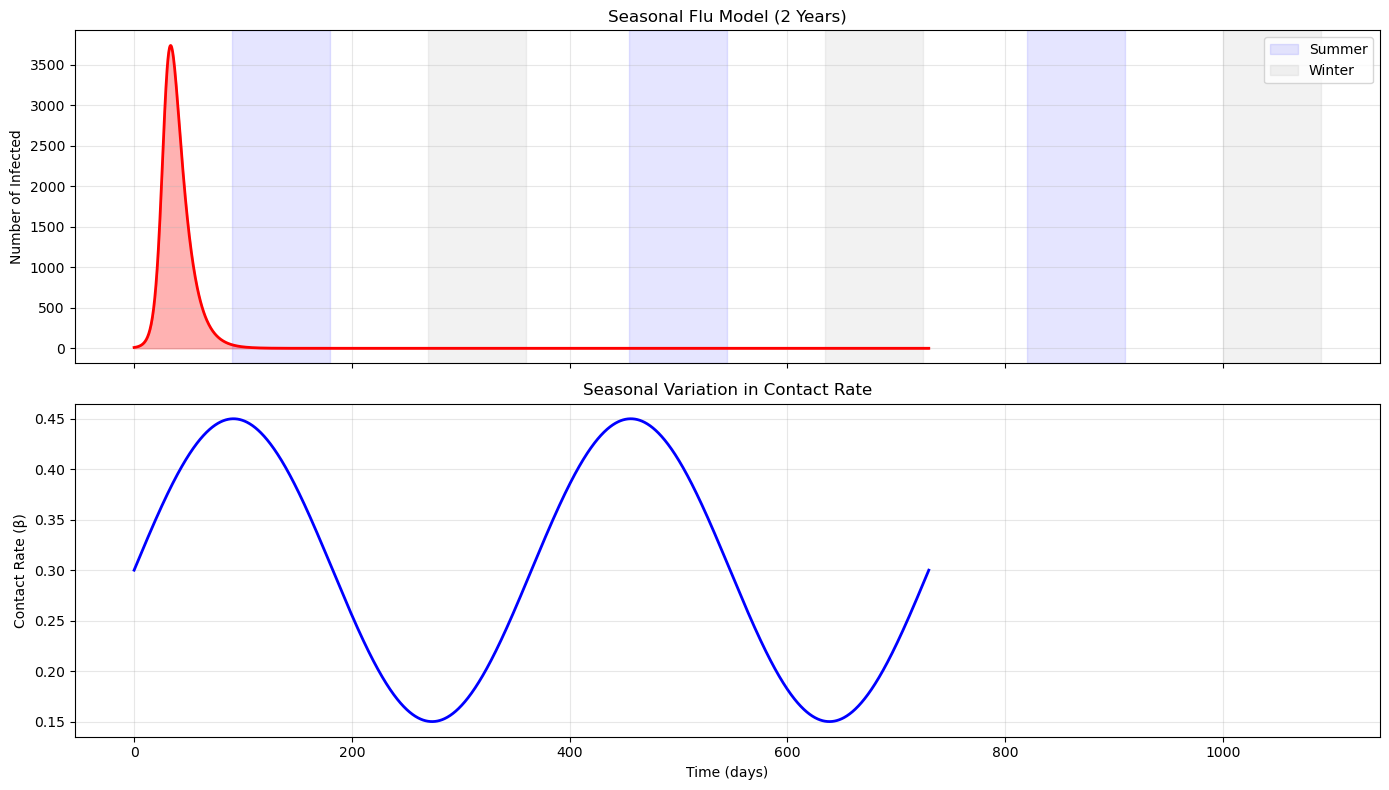

In [27]:
# 绘制结果
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# 上图：感染人数
ax1.plot(t_long, I_seasonal, 'r-', linewidth=2)
ax1.fill_between(t_long, 0, I_seasonal, alpha=0.3, color='red')
ax1.set_ylabel('Number of Infected')
ax1.set_title('Seasonal Flu Model (2 Years)')
ax1.grid(True, alpha=0.3)

# 标记季节
for year in range(3):
    ax1.axvspan(year*365 + 90, year*365 + 180, alpha=0.1, color='blue', label='Summer' if year==0 else '')
    ax1.axvspan(year*365 + 270, year*365 + 360, alpha=0.1, color='gray', label='Winter' if year==0 else '')

# 下图：接触率变化
beta_values = [seasonal_beta(t, beta_base, amplitude, 365) for t in t_long]
ax2.plot(t_long, beta_values, 'b-', linewidth=2)
ax2.set_xlabel('Time (days)')
ax2.set_ylabel('Contact Rate (β)')
ax2.set_title('Seasonal Variation in Contact Rate')
ax2.grid(True, alpha=0.3)

ax1.legend(loc='upper right')
plt.tight_layout()
plt.show()




## 敏感性分析



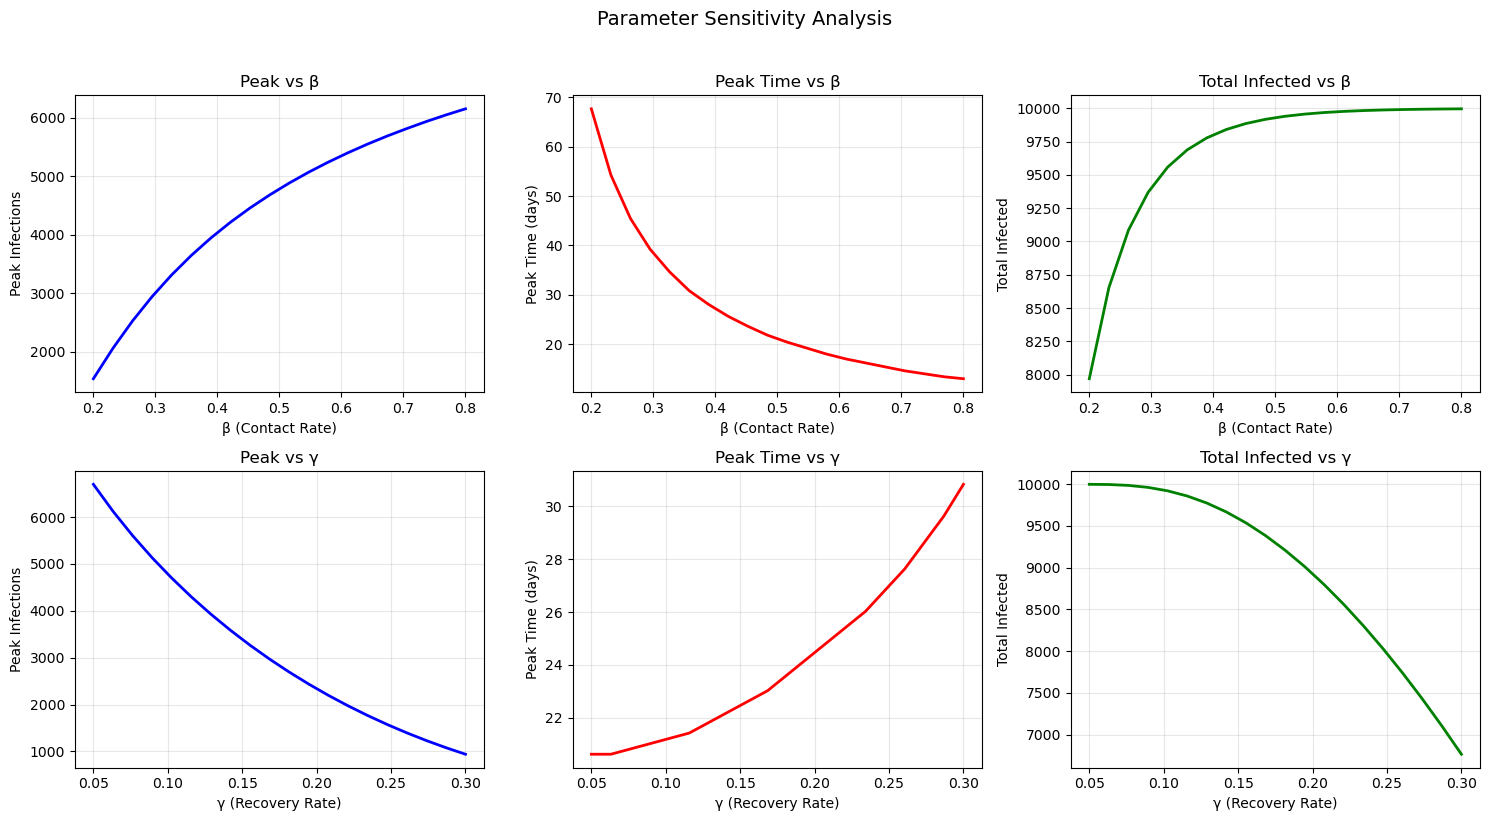

In [20]:
# ## 9. 模型验证与敏感性分析

print("\n## 敏感性分析\n")

# ### 9.1 参数敏感性分析

def sensitivity_analysis(param_name, param_range, base_params):
    """参数敏感性分析"""
    
    results = {
        'param_value': [],
        'peak_infections': [],
        'peak_time': [],
        'total_infected': []
    }
    
    for param_val in param_range:
        # 更新参数
        params = base_params.copy()
        params[param_name] = param_val
        
        # 求解模型
        solution = odeint(sir_model, y0, t, 
                         args=(params['beta'], params['gamma'], params['N']))
        S_temp, I_temp, R_temp = solution.T
        
        # 记录结果
        peak_idx = np.argmax(I_temp)
        results['param_value'].append(param_val)
        results['peak_infections'].append(I_temp[peak_idx])
        results['peak_time'].append(t[peak_idx])
        results['total_infected'].append(R_temp[-1])
    
    return pd.DataFrame(results)

# 基础参数
base_params = {'beta': 0.5, 'gamma': 0.1, 'N': N}

# 分析beta的敏感性
beta_range = np.linspace(0.2, 0.8, 20)
beta_sensitivity = sensitivity_analysis('beta', beta_range, base_params)

# 分析gamma的敏感性
gamma_range = np.linspace(0.05, 0.3, 20)
gamma_sensitivity = sensitivity_analysis('gamma', gamma_range, base_params)

# 绘制敏感性分析结果
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Beta敏感性
axes[0, 0].plot(beta_range, beta_sensitivity['peak_infections'], 'b-', linewidth=2)
axes[0, 0].set_xlabel('β (Contact Rate)')
axes[0, 0].set_ylabel('Peak Infections')
axes[0, 0].set_title('Peak vs β')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(beta_range, beta_sensitivity['peak_time'], 'r-', linewidth=2)
axes[0, 1].set_xlabel('β (Contact Rate)')
axes[0, 1].set_ylabel('Peak Time (days)')
axes[0, 1].set_title('Peak Time vs β')
axes[0, 1].grid(True, alpha=0.3)

axes[0, 2].plot(beta_range, beta_sensitivity['total_infected'], 'g-', linewidth=2)
axes[0, 2].set_xlabel('β (Contact Rate)')
axes[0, 2].set_ylabel('Total Infected')
axes[0, 2].set_title('Total Infected vs β')
axes[0, 2].grid(True, alpha=0.3)

# Gamma敏感性
axes[1, 0].plot(gamma_range, gamma_sensitivity['peak_infections'], 'b-', linewidth=2)
axes[1, 0].set_xlabel('γ (Recovery Rate)')
axes[1, 0].set_ylabel('Peak Infections')
axes[1, 0].set_title('Peak vs γ')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(gamma_range, gamma_sensitivity['peak_time'], 'r-', linewidth=2)
axes[1, 1].set_xlabel('γ (Recovery Rate)')
axes[1, 1].set_ylabel('Peak Time (days)')
axes[1, 1].set_title('Peak Time vs γ')
axes[1, 1].grid(True, alpha=0.3)

axes[1, 2].plot(gamma_range, gamma_sensitivity['total_infected'], 'g-', linewidth=2)
axes[1, 2].set_xlabel('γ (Recovery Rate)')
axes[1, 2].set_ylabel('Total Infected')
axes[1, 2].set_title('Total Infected vs γ')
axes[1, 2].grid(True, alpha=0.3)

plt.suptitle('Parameter Sensitivity Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()



In [21]:
# ## 10. 总结与思考

print("\n## 练习总结\n")
print("通过本练习，我们学习了：")
print("1. ✓ SIR模型的数学原理和数值求解")
print("2. ✓ 基本再生数R₀的意义和计算")
print("3. ✓ 防控措施对疫情发展的影响")
print("4. ✓ 疫苗接种策略的效果评估")
print("5. ✓ 参数敏感性分析方法")
print("\n思考题：")
print("• 如何将人口的年龄结构纳入模型？")
print("• 如何考虑空间因素（不同地区的传播）？")
print("• 如何处理参数的不确定性？")
print("\n下一步学习建议：")
print("→ 尝试实现SEIR模型")
print("→ 使用真实数据进行参数拟合")
print("→ 探索网络传播模型")


## 练习总结

通过本练习，我们学习了：
1. ✓ SIR模型的数学原理和数值求解
2. ✓ 基本再生数R₀的意义和计算
3. ✓ 防控措施对疫情发展的影响
4. ✓ 疫苗接种策略的效果评估
5. ✓ 参数敏感性分析方法

思考题：
• 如何将人口的年龄结构纳入模型？
• 如何考虑空间因素（不同地区的传播）？
• 如何处理参数的不确定性？

下一步学习建议：
→ 尝试实现SEIR模型
→ 使用真实数据进行参数拟合
→ 探索网络传播模型
